# Toy KV-Cache Demo

A minimal decoder-only (GPT-style) transformer, compared with and without a
KV cache during autoregressive generation. The model and generation code
live in `model.py` (`TinyGPT`, `generate_no_cache`, `generate_with_cache`) —
this notebook imports them and focuses on: a correctness check that the two
paths are equivalent, and a benchmark showing how caching avoids repeated
full-prefix computation, on CPU and (if available) Apple Silicon MPS.

Weights are randomly initialized — no training. The point is the systems
tradeoff, not language modeling quality.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from model import ModelConfig, TinyGPT, generate_no_cache, generate_with_cache

torch.manual_seed(0)


Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/luoxuhao/.cache/fontconfig
	/Users/luoxuhao/.fontconfig


Matplotlib is building the font cache; this may take a moment.


## Device selection

In [2]:
DEFAULT_DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DEVICES = ["cpu"] + (["mps"] if torch.backends.mps.is_available() else [])
print("default device:", DEFAULT_DEVICE)
print("benchmarking on:", DEVICES)

default device: mps
benchmarking on: ['cpu', 'mps']


## Tiny character-level tokenizer

In [3]:
corpus = (
    "the quick brown fox jumps over the lazy dog. "
    "she sells seashells by the seashore. "
    "how much wood would a woodchuck chuck if a woodchuck could chuck wood? "
    "to be or not to be, that is the question."
)
chars = sorted(set(corpus))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[i] for i in ids)

print(f"vocab_size = {vocab_size}")
print(chars)

vocab_size = 30
[' ', ',', '.', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## Model

In [4]:
cfg = ModelConfig(vocab_size=vocab_size, n_layers=1, d_model=64, n_heads=4, max_seq_len=2048)

model = TinyGPT(cfg).to(DEFAULT_DEVICE)
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"n_layers={cfg.n_layers}, d_model={cfg.d_model}, n_heads={cfg.n_heads}, params={n_params:,}")

n_layers=1, d_model=64, n_heads=4, params=185,024


## Correctness check

`generate_no_cache` recomputes the full forward pass over the whole
sequence at every step. `generate_with_cache` forwards only the newest
token and reuses a per-layer K/V cache for everything before it. Both call
the same `CausalSelfAttention.forward`, so with the same weights, prompt,
and greedy decoding (argmax, no sampling) they must produce identical token
ids -- this is the check that the cache is mathematically equivalent, not
just faster.

In [5]:
prompt_text = "the quick "
prompt_ids = torch.tensor([encode(prompt_text)], dtype=torch.long)
n_check_tokens = 40

out_no_cache = generate_no_cache(model, prompt_ids, n_check_tokens, DEFAULT_DEVICE)
out_with_cache = generate_with_cache(model, prompt_ids, n_check_tokens, DEFAULT_DEVICE)

assert torch.equal(out_no_cache.cpu(), out_with_cache.cpu()), "cache and no-cache generations diverged!"
print("correctness check passed: identical token ids with/without cache\n")
print("no_cache  :", repr(decode(out_no_cache[0].cpu().tolist())))
print("with_cache:", repr(decode(out_with_cache[0].cpu().tolist())))

correctness check passed: identical token ids with/without cache

no_cache  : 'the quick jbxin jljqop.jso?ljbjscvscvaoh,ixrscvstd'
with_cache: 'the quick jbxin jljqop.jso?ljbjscvscvaoh,ixrscvstd'


## Benchmark

For each device and each target generation length, time both modes
end-to-end (min of several repeats, with an untimed warmup run first --
this matters especially on MPS, which lazily compiles kernels on first
use). This produces the cumulative-time-vs-length comparison.

In [6]:
def timed_generate(gen_fn, model, prompt_ids, n_new_tokens, device, repeats=3):
    times = []
    for _ in range(repeats):
        if device == "mps":
            torch.mps.synchronize()
        t0 = time.perf_counter()
        gen_fn(model, prompt_ids, n_new_tokens, device)
        if device == "mps":
            torch.mps.synchronize()
        times.append(time.perf_counter() - t0)
    return min(times)


lengths = [32, 64, 128, 256, 512, 1024]
cumulative = {}  # cumulative[(device, mode)] = [time per length]

for dev in DEVICES:
    dev_model = TinyGPT(cfg).to(dev)
    dev_model.load_state_dict(model.state_dict())
    dev_model.eval()

    # warmup (untimed) -- triggers MPS kernel compilation
    timed_generate(generate_no_cache, dev_model, prompt_ids, 8, dev, repeats=1)
    timed_generate(generate_with_cache, dev_model, prompt_ids, 8, dev, repeats=1)

    for mode, gen_fn in [("no_cache", generate_no_cache), ("cache", generate_with_cache)]:
        times = []
        for n in lengths:
            t = timed_generate(gen_fn, dev_model, prompt_ids, n, dev, repeats=3)
            times.append(t)
            print(f"{dev:>4} | {mode:>8} | n={n:>4} | {t*1000:8.2f} ms")
        cumulative[(dev, mode)] = times

 cpu | no_cache | n=  32 |    11.80 ms
 cpu | no_cache | n=  64 |    29.03 ms


 cpu | no_cache | n= 128 |    70.63 ms


 cpu | no_cache | n= 256 |   210.48 ms


 cpu | no_cache | n= 512 |   811.75 ms


 cpu | no_cache | n=1024 |  4296.36 ms
 cpu |    cache | n=  32 |     6.04 ms
 cpu |    cache | n=  64 |    12.05 ms
 cpu |    cache | n= 128 |    24.78 ms


...

 mps |    cache | n=  64 |   295.83 ms


 mps |    cache | n= 128 |   652.15 ms


 mps |    cache | n= 256 |  1198.43 ms


 mps |    cache | n= 512 |  2274.85 ms


 mps |    cache | n=1024 |  5406.28 ms


### Cumulative generation time vs. sequence length

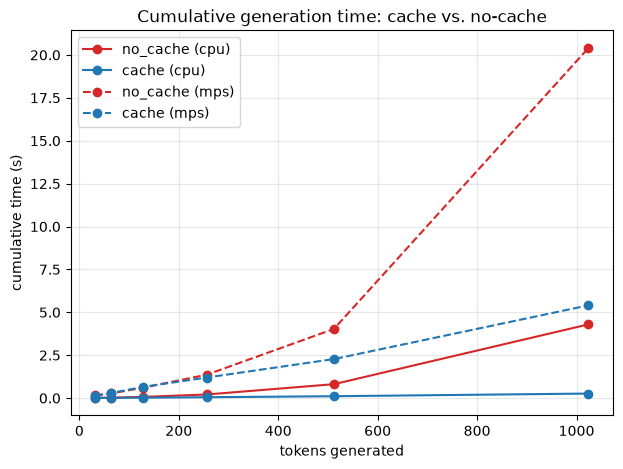

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
styles = {"cpu": "-", "mps": "--"}
colors = {"no_cache": "tab:red", "cache": "tab:blue"}

for (dev, mode), times in cumulative.items():
    ax.plot(
        lengths, times,
        linestyle=styles[dev], color=colors[mode], marker="o",
        label=f"{mode} ({dev})",
    )

ax.set_xlabel("tokens generated")
ax.set_ylabel("cumulative time (s)")
ax.set_title("Cumulative generation time: cache vs. no-cache")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Per-step time at a fixed length

Same comparison, but showing time for each individual generation step
rather than the cumulative total. With standard full attention, no-cache
step time should grow roughly quadratically with position, while cached
step time should grow roughly linearly as it attends to the cached prefix.

In [8]:
fixed_length = 256
per_step = {}  # per_step[(device, mode)] = [time per step]

for dev in DEVICES:
    dev_model = TinyGPT(cfg).to(dev)
    dev_model.load_state_dict(model.state_dict())
    dev_model.eval()

    _, t_no_cache = generate_no_cache(dev_model, prompt_ids, fixed_length, dev, record_times=True)
    _, t_cache = generate_with_cache(dev_model, prompt_ids, fixed_length, dev, record_times=True)
    per_step[(dev, "no_cache")] = t_no_cache
    per_step[(dev, "cache")] = t_cache

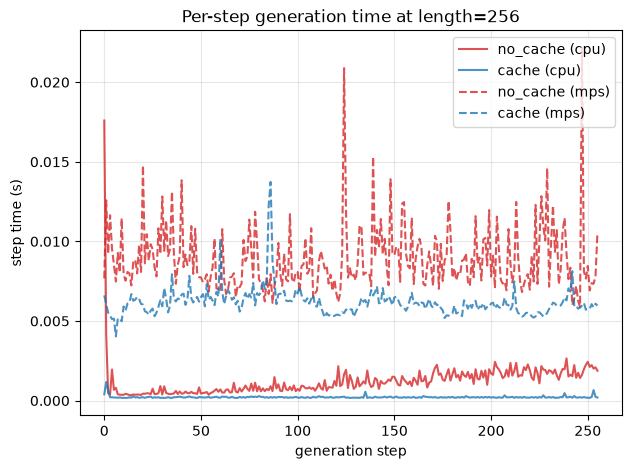

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

for (dev, mode), times in per_step.items():
    ax.plot(
        range(len(times)), times,
        linestyle=styles[dev], color=colors[mode],
        label=f"{mode} ({dev})", alpha=0.8,
    )

ax.set_xlabel("generation step")
ax.set_ylabel("step time (s)")
ax.set_title(f"Per-step generation time at length={fixed_length}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Takeaways

- The correctness check confirms the KV cache is an exact optimization,
  not an approximation: same weights, same prompt, same output.
- No-cache generation redoes attention over the whole prefix at every step.
  For standard full attention, that is O(n^3) attention work across a
  generation, versus O(n^2) with a cache; caching also avoids recomputing
  old K/V projections and earlier-token activations.
- Check the printed per-device numbers and the two plots above to see
  whether MPS actually beat CPU at this model's tiny scale, or whether
  per-op dispatch overhead ate the advantage.